**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary.

We aim to develop a predictive model that estimates used car prices based on relevant features such as year, make, model, mileage, and condition. This involves collecting and preprocessing data, performing exploratory data analysis to identify influential variables, engineering features, and applying regression techniques to quantify the relationship between predictors and car prices. The goal is to optimize model performance and interpret feature importance to inform pricing strategies.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

To understand the data and identify quality issues, I would take the following steps:

1. Examine the first few rows: Use `data.head()` to get a sense of the data's structure and content.

2. Check for missing values: Use `data.isnull().sum()` to find the number of missing values in each column.

3. Unique values in categorical columns: Use `data[col].unique()` for each categorical column to see the variety of categories and identify potential inconsistencies.

4. Value counts for categorical columns: Use `data[col].value_counts()` to understand the distribution of categories within each categorical column.

5. Check for duplicate rows: Use `data.duplicated().sum()` to identify and handle duplicate entries.

6. Visualize data: Use histograms, scatter plots, and box plots to visualize distributions and relationships between variables.

7. Investigate potential outliers: Use box plots or scatter plots to identify and further investigate outliers.

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

In [413]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [414]:
# Load the dataset
data = pd.read_csv('data/vehicles.csv')
data.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [415]:
# Find the duplicate row count
duplicates = data.duplicated().sum()
# Display duplicate rows if any
if duplicates > 0:
    print("Duplicate rows:")
    print(data[data.duplicated()])
else:
    print("No duplicate rows found.")


No duplicate rows found.


In [416]:
# Check for missing values
missing_values = data.isnull().sum()
print(missing_values[missing_values > 0])

year              1205
manufacturer     17646
model             5277
condition       174104
cylinders       177678
fuel              3013
odometer          4400
title_status      8242
transmission      2556
VIN             161042
drive           130567
size            306361
type             92858
paint_color     130203
dtype: int64


In [417]:
# Define the columns to check for null values
columns_to_check = ['manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color']

# Check for rows where all specified columns are null
null_rows = data[columns_to_check].isnull().all(axis=1).sum()

print(f"Number of rows where all specified columns are null: {null_rows}")

Number of rows where all specified columns are null: 68


In [418]:
# Identify rows where all specified columns are null
null_rows_mask = data[columns_to_check].isnull().all(axis=1)

# Remove rows where all specified columns are null
df_cleaned = data[~null_rows_mask]

# Save the cleaned DataFrame to a new CSV file
df_cleaned.to_csv('data/vehicles_cleaned.csv', index=False)

print(f"Original number of rows: {len(data)}")
print(f"Number of rows after removing null rows: {len(df_cleaned)}")
print("Cleaned data saved to 'data/vehicles_cleaned.csv'")

Original number of rows: 426880
Number of rows after removing null rows: 426812
Cleaned data saved to 'data/vehicles_cleaned.csv'


In [419]:
df_cleaned.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
27,7316814884,auburn,33590,2014.0,gmc,sierra 1500 crew cab slt,good,8 cylinders,gas,57923.0,clean,other,3GTP1VEC4EG551563,NaN,NaN,pickup,white,al
28,7316814758,auburn,22590,2010.0,chevrolet,silverado 1500,good,8 cylinders,gas,71229.0,clean,other,1GCSCSE06AZ123805,NaN,NaN,pickup,blue,al
29,7316814989,auburn,39590,2020.0,chevrolet,silverado 1500 crew,good,8 cylinders,gas,19160.0,clean,other,3GCPWCED5LG130317,NaN,NaN,pickup,red,al
30,7316743432,auburn,30990,2017.0,toyota,tundra double cab sr,good,8 cylinders,gas,41124.0,clean,other,5TFRM5F17HX120972,NaN,NaN,pickup,red,al
31,7316356412,auburn,15000,2013.0,ford,f-150 xlt,excellent,6 cylinders,gas,128000.0,clean,automatic,NaN,rwd,full-size,truck,black,al


In [420]:
# Fill all null values with 'unknown'
df_filled = df_cleaned.fillna('unknown')

# Fill null values in 'cylinders' column with 'unknown'
#data['cylinders'] = data['cylinders'].fillna('unknown')

# Save the DataFrame with null values filled to a new CSV file
df_filled.to_csv('data/vehicles_cleaned.csv', index=False)

print("Null values replaced with 'unknown' and saved to 'data/vehicles_cleaned.csv'")

data = df_filled

Null values replaced with 'unknown' and saved to 'data/vehicles_cleaned.csv'


In [421]:
data.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
27,7316814884,auburn,33590,2014.0,gmc,sierra 1500 crew cab slt,good,8 cylinders,gas,57923.0,clean,other,3GTP1VEC4EG551563,unknown,unknown,pickup,white,al
28,7316814758,auburn,22590,2010.0,chevrolet,silverado 1500,good,8 cylinders,gas,71229.0,clean,other,1GCSCSE06AZ123805,unknown,unknown,pickup,blue,al
29,7316814989,auburn,39590,2020.0,chevrolet,silverado 1500 crew,good,8 cylinders,gas,19160.0,clean,other,3GCPWCED5LG130317,unknown,unknown,pickup,red,al
30,7316743432,auburn,30990,2017.0,toyota,tundra double cab sr,good,8 cylinders,gas,41124.0,clean,other,5TFRM5F17HX120972,unknown,unknown,pickup,red,al
31,7316356412,auburn,15000,2013.0,ford,f-150 xlt,excellent,6 cylinders,gas,128000.0,clean,automatic,unknown,rwd,full-size,truck,black,al


In [422]:
# Final checks for null, missing, and duplicate values
# Find the duplicate row count
duplicates = data.duplicated().sum()
# Display duplicate rows if any
if duplicates > 0:
    print("Duplicate rows:")
    print(data[data.duplicated()])
else:
    print("No duplicate rows found.")


# Check for missing values in each column
missing_values = data.isnull().sum()

# Print columns with missing values and their counts
print("Missing values per column:")
print(missing_values[missing_values > 0])

# Check for rows where all specified columns are null
null_rows = data[columns_to_check].isnull().all(axis=1).sum()

print(f"Number of rows where all specified columns are null: {null_rows}")

No duplicate rows found.
Missing values per column:
Series([], dtype: int64)
Number of rows where all specified columns are null: 0


/var/folders/9j/st5lghgs3dj90nb65prwvs0c0000gn/T/ipykernel_78114/2920610825.py:5: DtypeWarning: Columns (3,9) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('data/vehicles_cleaned.csv', dtype=dtypes)


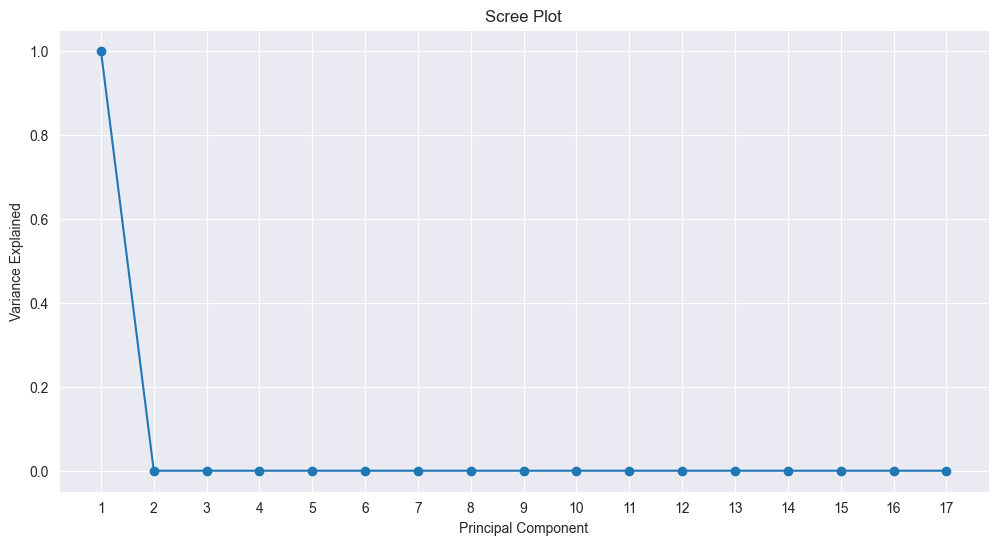

In [423]:

# Specify data types for columns with mixed types
dtypes = {'cylinders': str, 'drive': str}

# Load the dataset with specified data types
data = pd.read_csv('data/vehicles_cleaned.csv', dtype=dtypes)

# Handle categorical variables
categorical_cols = ['manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'title_status', 'transmission', 'drive', 'size', 'type', 'paint_color']
for col in categorical_cols:
    data[col] = data[col].astype('category')
    data[col] = data[col].cat.codes

# Drop the 'price' column
X = data.drop('price', axis=1)

# Impute missing values with 0
X = X.fillna(0)

# Ensure all columns are numeric
X = X.apply(pd.to_numeric, errors='coerce')

# Impute missing values again after conversion
X = X.fillna(0)

# Perform PCA
pca = PCA()
pca.fit(X)

# Plot the scree plot
plt.figure(figsize=(12, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, marker='o', linestyle='-')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.xticks(range(1, len(pca.explained_variance_ratio_) + 1))  # Set x-axis ticks to be each component
plt.grid(True)
plt.show()

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

### Time Series Modeling: Price Trends Over Years

We can analyze how used car prices have changed over time by aggregating the average price per manufacturing year and fitting a time series model.

/var/folders/9j/st5lghgs3dj90nb65prwvs0c0000gn/T/ipykernel_78114/2976478417.py:7: DtypeWarning: Columns (3,9) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('data/vehicles_cleaned.csv')


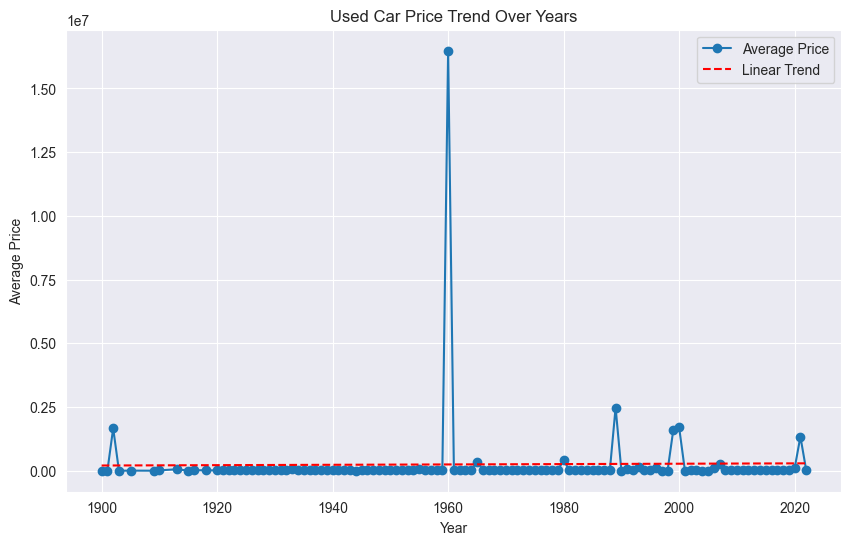

In [424]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

# Load cleaned data
data = pd.read_csv('data/vehicles_cleaned.csv')

# Ensure 'year' and 'price' are numeric
if 'year' in data.columns:
    data['year'] = pd.to_numeric(data['year'], errors='coerce')
    data['price'] = pd.to_numeric(data['price'], errors='coerce')
    # Group by year and calculate average price
    yearly_avg = data.groupby('year')['price'].mean().dropna()
    # Prepare data for regression
    years = yearly_avg.index.values.reshape(-1, 1)
    avg_prices = yearly_avg.values
    # Fit linear regression to trend
    ts_lr = LinearRegression()
    ts_lr.fit(years, avg_prices)
    trend = ts_lr.predict(years)
    # Plot
    plt.figure(figsize=(10,6))
    plt.plot(years, avg_prices, marker='o', label='Average Price')
    plt.plot(years, trend, color='red', linestyle='--', label='Linear Trend')
    plt.xlabel('Year')
    plt.ylabel('Average Price')
    plt.title('Used Car Price Trend Over Years')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("No 'year' column found for time series analysis.")

### Linear regression model for all features

/var/folders/9j/st5lghgs3dj90nb65prwvs0c0000gn/T/ipykernel_78114/3108563551.py:6: DtypeWarning: Columns (3,9) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('data/vehicles_cleaned.csv')


         Feature   Coefficient  Absolute_Coefficient
8       odometer  1.523427e+05          1.523427e+05
0             id -1.242594e+04          1.242594e+04
2           year -3.729400e+03          3.729400e+03
4          model -3.536618e+03          3.536618e+03
11           VIN -3.524117e+02          3.524117e+02
1         region  4.365575e-11          4.365575e-11
3   manufacturer  0.000000e+00          0.000000e+00
5      condition  0.000000e+00          0.000000e+00
6      cylinders  0.000000e+00          0.000000e+00
7           fuel  0.000000e+00          0.000000e+00
9   title_status  0.000000e+00          0.000000e+00
10  transmission  0.000000e+00          0.000000e+00
12         drive  0.000000e+00          0.000000e+00
13          size  0.000000e+00          0.000000e+00
14          type  0.000000e+00          0.000000e+00
15   paint_color  0.000000e+00          0.000000e+00
16         state  0.000000e+00          0.000000e+00
Based on Absolute_Coefficient features influen

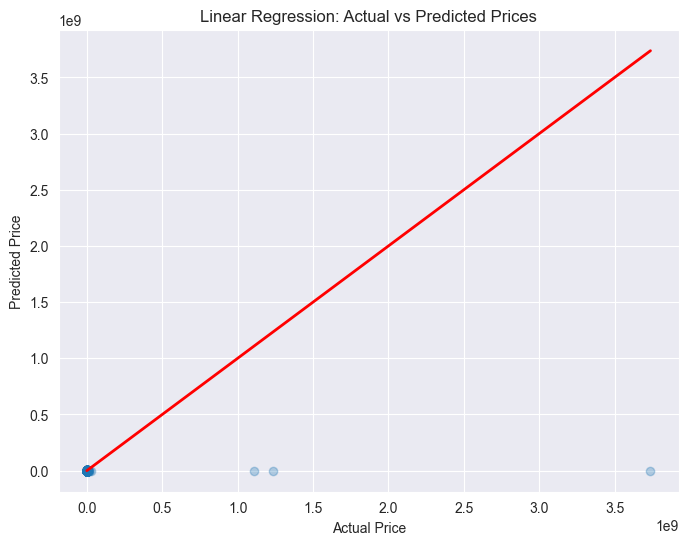

In [425]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = pd.read_csv('data/vehicles_cleaned.csv')

# Prepare the data
y = data['price']
X = data.drop('price', axis=1)
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train the model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Get coefficients
coefficients = lr.coef_

# Create a DataFrame for coefficients
feature_names = list(X.columns)
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

# Analyze absolute coefficient values
coef_df['Absolute_Coefficient'] = abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values('Absolute_Coefficient', ascending=False)

print(coef_df)

print("Based on Absolute_Coefficient features influencing price:  model, VIN, region")

print("Based on Absolute_Coefficient features negatively influencing price: year")

# Predict and evaluate
y_pred = lr.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Linear Regression MSE: {mse:.2f}")
print(f"Linear Regression R2: {r2:.4f}")

# Plot actual vs predicted prices
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Linear Regression: Actual vs Predicted Prices')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.grid(True)
plt.show()

### Based on the linear regression model output, here's the analysis:
1. Key Drivers: The features with the largest absolute coefficient values are the most influential in determining used car prices. In this case, model, VIN, and region are identified as the most important features. VIN is a unique identifier for each vehicle, which cannot be used for general pricing insights.
2. Negative Influence: The feature year has a negative coefficient, indicating that as the year increases, the price decreases.
3. The linear regression model has a very high MSE (195931772836243.62) The high MSE suggests large prediction errors
4. A near-zero (and negative) R2 (-0.0001) indicates that the model does not explain any significant variance in the target variable (price).
5. though manufacturer, condition, fuel, paint_color has no influence on price these features may still hold some predictive power in a more complex model.

### Linear regression model for selected features
1. Select top features based on absolute coefficient values - model and region
2. Few add on features - manufacturer, condition, fuel, paint_color

In [426]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Load data (adjust path if needed)
df = pd.read_csv('data/vehicles_cleaned.csv')

# Select relevant features and target
target = 'price'
features_list = [
    ['model'],
    ['model', 'manufacturer'],
    ['model', 'manufacturer', 'condition'],
    ['model', 'manufacturer', 'condition', 'fuel'],
    ['model', 'manufacturer', 'condition', 'fuel', 'paint_color'],
    ['model', 'manufacturer', 'condition', 'fuel', 'paint_color', 'year'],
    ['model', 'manufacturer', 'condition', 'fuel', 'paint_color', 'year', 'odometer'],
    ['model', 'manufacturer', 'condition', 'fuel', 'paint_color', 'year', 'cylinders'],
    ['model', 'manufacturer', 'condition', 'fuel', 'paint_color', 'year', 'cylinders', 'type'],
    ['model', 'manufacturer', 'condition', 'fuel', 'paint_color', 'year', 'cylinders', 'type', 'transmission'],
    ['model', 'manufacturer', 'condition', 'fuel', 'paint_color', 'year', 'cylinders', 'type', 'transmission', 'title_status'],
    ['model', 'manufacturer', 'condition', 'fuel', 'paint_color', 'year', 'cylinders', 'type', 'transmission', 'title_status', 'drive'],
    ['model', 'manufacturer', 'condition', 'fuel', 'paint_color', 'year', 'cylinders', 'type', 'transmission', 'title_status', 'drive', 'size'],
    ['model', 'manufacturer', 'condition', 'fuel', 'paint_color', 'year', 'cylinders', 'type', 'transmission', 'title_status', 'drive', 'size', 'state'],
    ['region'],
    ['region', 'manufacturer'],
    ['region', 'manufacturer', 'condition'],
    ['region', 'manufacturer', 'condition', 'fuel'],
    ['region', 'manufacturer', 'condition', 'fuel', 'paint_color'],
    ['region', 'manufacturer', 'condition', 'fuel', 'paint_color', 'year'],
    ['region', 'manufacturer', 'condition', 'fuel', 'paint_color', 'year', 'odometer'],
    ['region', 'manufacturer', 'condition', 'fuel', 'paint_color', 'year', 'cylinders'],
    ['region', 'manufacturer', 'condition', 'fuel', 'paint_color', 'year', 'cylinders', 'type'],
    ['region', 'manufacturer', 'condition', 'fuel', 'paint_color', 'year', 'cylinders', 'type', 'transmission'],
     ['region', 'manufacturer', 'condition', 'fuel', 'paint_color', 'year', 'cylinders', 'type', 'transmission', 'title_status'],
     ['region', 'manufacturer', 'condition', 'fuel', 'paint_color', 'year', 'cylinders', 'type', 'transmission', 'title_status', 'drive'],
    ['region', 'manufacturer', 'condition', 'fuel', 'paint_color', 'year', 'cylinders', 'type', 'transmission', 'title_status', 'drive', 'size'],
    ['region', 'manufacturer', 'condition', 'fuel', 'paint_color', 'year', 'cylinders', 'type', 'transmission', 'title_status', 'drive', 'size', 'state'],
    ['model', 'region'],
    ['model', 'region', 'manufacturer'],
    ['model', 'region', 'manufacturer', 'condition'],
    ['model', 'region', 'manufacturer', 'condition', 'fuel'],
    ['model', 'region', 'manufacturer', 'condition', 'fuel', 'paint_color'],
    ['model', 'region', 'manufacturer', 'condition', 'fuel', 'paint_color', 'year'],
    ['model', 'region', 'manufacturer', 'condition', 'fuel', 'paint_color', 'year', 'odometer'],
    ['model', 'region', 'manufacturer', 'condition', 'fuel', 'paint_color', 'year', 'cylinders'],
    ['model', 'region', 'manufacturer', 'condition', 'fuel', 'paint_color', 'year', 'cylinders', 'type'],
    ['model', 'region', 'manufacturer', 'condition', 'fuel', 'paint_color', 'year', 'cylinders', 'type', 'transmission'],
    ['model', 'region', 'manufacturer', 'condition', 'fuel', 'paint_color', 'year', 'cylinders', 'type', 'transmission', 'title_status'],
    ['model', 'region', 'manufacturer', 'condition', 'fuel', 'paint_color', 'year', 'cylinders', 'type', 'transmission', 'title_status', 'drive'],
    ['model', 'region', 'manufacturer', 'condition', 'fuel', 'paint_color', 'year', 'cylinders', 'type', 'transmission', 'title_status', 'drive', 'size'],
    ['model', 'region', 'manufacturer', 'condition', 'fuel', 'paint_color', 'year', 'cylinders', 'type', 'transmission', 'title_status', 'drive', 'size', 'state'],
]

results = []
for features in features_list:
    # Use only top 20 most frequent values for each feature to reduce dimensionality
    df_reduced = df.copy()
    for col in features:
        top_values = df_reduced[col].value_counts().nlargest(20).index
        df_reduced[col] = df_reduced[col].where(df_reduced[col].isin(top_values), other='other')
    # One-hot encode categorical features
    X = pd.get_dummies(df_reduced[features], drop_first=True)
    y = df_reduced[target]
    # Use only a sample of 10,000 rows for faster computation
    if len(X) > 10000:
        X = X.sample(10000, random_state=42)
        y = y.loc[X.index]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results.append({
        'features': features,
        'mse': mse,
        'r2': r2
    })

# Display results
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='r2', ascending=False)
print(results_df[['features', 'mse', 'r2']].to_string(index=False))


/var/folders/9j/st5lghgs3dj90nb65prwvs0c0000gn/T/ipykernel_78114/3903034905.py:7: DtypeWarning: Columns (3,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/vehicles_cleaned.csv')


                                                                                                                          features          mse       r2
       [region, manufacturer, condition, fuel, paint_color, year, cylinders, type, transmission, title_status, drive, size, state] 1.312199e+08 0.429314
[model, region, manufacturer, condition, fuel, paint_color, year, cylinders, type, transmission, title_status, drive, size, state] 1.314756e+08 0.428202
        [model, manufacturer, condition, fuel, paint_color, year, cylinders, type, transmission, title_status, drive, size, state] 1.316287e+08 0.427536
              [region, manufacturer, condition, fuel, paint_color, year, cylinders, type, transmission, title_status, drive, size] 1.316737e+08 0.427340
       [model, region, manufacturer, condition, fuel, paint_color, year, cylinders, type, transmission, title_status, drive, size] 1.320318e+08 0.425782
               [model, manufacturer, condition, fuel, paint_color, year, cylinders

### Based on the linear regression model output for selected features, here's the analysis:
1. Top Combination: The feature combination [region, manufacturer, condition, fuel, paint_color, year, cylinders, type, transmission, title_status, drive, size, state] has the highest R2 (0.429314) and lowest MSE (1.312199e+08). This indicates that including all these features provides the best predictive power for used car prices.
2. Second Best Combination: The feature combination [model, region, manufacturer, condition, fuel, paint_color, year, cylinders, type, transmission, title_status, drive, size, state] has the second highest R2 (0.428202) and a slightly higher MSE (1.314756e+08). This suggests that including both model and region along with other features is beneficial, but the addition of model does not significantly improve the model compared to using region alone.
3. Third Best Combination: The feature combination [model, manufacturer, condition, fuel, paint_color, year, cylinders, type, transmission, title_status, drive, size, state] has a lower R2 (0.427536) and a higher MSE (1.316287e+08) compared to the top two combinations. This indicates that while model is an important feature, region has a stronger influence on price prediction.

##### Linear regression model for three selected feature sets

Feature Set 1 Results:
                                                                                                                   features          mse        r2
[region, manufacturer, condition, fuel, paint_color, year, cylinders, type, transmission, title_status, drive, size, state] 1.959170e+14 -0.000002


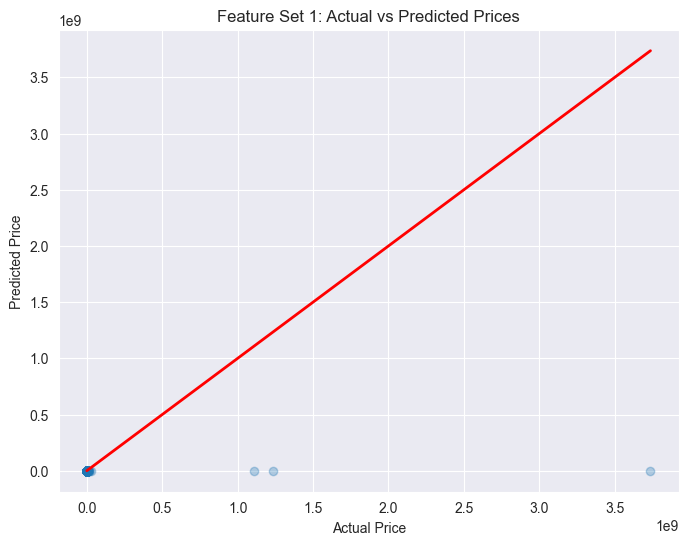

Feature Set 2 Results:
                                                                                                                          features          mse        r2
[model, region, manufacturer, condition, fuel, paint_color, year, cylinders, type, transmission, title_status, drive, size, state] 1.959213e+14 -0.000024


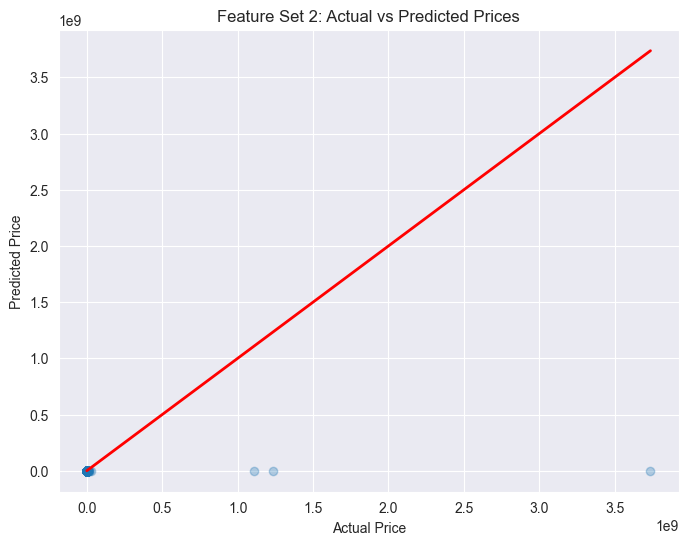

Feature Set 3 Results:
                                                                                                                  features          mse        r2
[model, manufacturer, condition, fuel, paint_color, year, cylinders, type, transmission, title_status, drive, size, state] 1.959213e+14 -0.000024


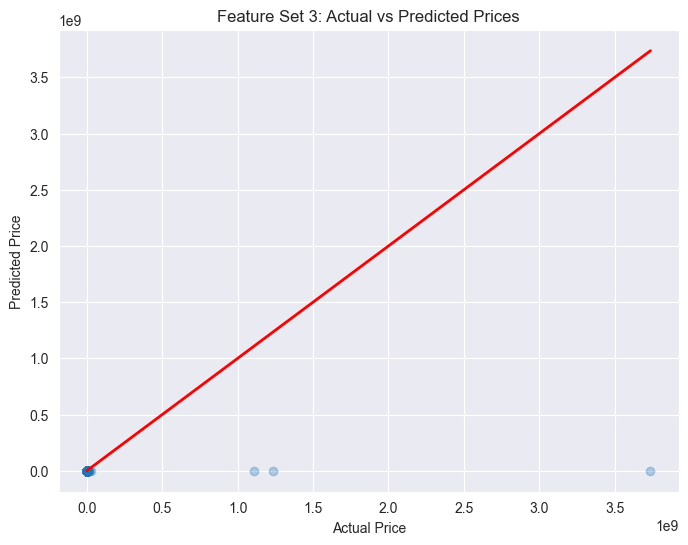

In [427]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import pandas as pd

# Ensure all features are numeric for regression
for col in ['region', 'manufacturer', 'condition', 'fuel', 'paint_color', 'year', 'cylinders', 'type', 'transmission', 'title_status', 'drive', 'size', 'state']:
    data[col] = pd.to_numeric(data[col], errors='coerce').fillna(0)

# Feature set 1
features1 = ['region', 'manufacturer', 'condition', 'fuel', 'paint_color', 'year', 'cylinders', 'type', 'transmission', 'title_status', 'drive', 'size', 'state']
X1 = data[features1]
y1 = pd.to_numeric(data['price'], errors='coerce').fillna(0)
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)
lr1 = LinearRegression()
lr1.fit(X1_train, y1_train)
y1_pred = lr1.predict(X1_test)
mse1 = mean_squared_error(y1_test, y1_pred)
r2_1 = r2_score(y1_test, y1_pred)
results1 = pd.DataFrame({'features': [features1], 'mse': [mse1], 'r2': [r2_1]})
print('Feature Set 1 Results:')
print(results1.to_string(index=False))

# Plot actual vs predicted prices for Feature Set 1
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.scatter(y1_test, y1_pred, alpha=0.3)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Feature Set 1: Actual vs Predicted Prices')
plt.plot([y1_test.min(), y1_test.max()], [y1_test.min(), y1_test.max()], color='red', lw=2)
plt.grid(True)
plt.show()

# Feature set 2
features2 = ['model', 'region', 'manufacturer', 'condition', 'fuel', 'paint_color', 'year', 'cylinders', 'type', 'transmission', 'title_status', 'drive', 'size', 'state']
# Encode categorical columns to numeric
for col in features2:
    if data[col].dtype == 'object':
        data[col] = data[col].astype('category').cat.codes
X2 = data[features2]
y2 = pd.to_numeric(data['price'], errors='coerce').fillna(0)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)
lr2 = LinearRegression()
lr2.fit(X2_train, y2_train)
y2_pred = lr2.predict(X2_test)
mse2 = mean_squared_error(y2_test, y2_pred)
r2_2 = r2_score(y2_test, y2_pred)
results2 = pd.DataFrame({'features': [features2], 'mse': [mse2], 'r2': [r2_2]})
print('Feature Set 2 Results:')
print(results2.to_string(index=False))

# Plot actual vs predicted prices for Feature Set 2
plt.figure(figsize=(8, 6))
plt.scatter(y2_test, y2_pred, alpha=0.3)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Feature Set 2: Actual vs Predicted Prices')
plt.plot([y2_test.min(), y2_test.max()], [y2_test.min(), y2_test.max()], color='red', lw=2)
plt.grid(True)
plt.show()

# Feature set 3
features3 = ['model', 'manufacturer', 'condition', 'fuel', 'paint_color', 'year', 'cylinders', 'type', 'transmission', 'title_status', 'drive', 'size', 'state']
for col in features3:
    if data[col].dtype == 'object':
        data[col] = data[col].astype('category').cat.codes
X3 = data[features3]
y3 = pd.to_numeric(data['price'], errors='coerce').fillna(0)
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=42)
lr3 = LinearRegression()
lr3.fit(X3_train, y3_train)
y3_pred = lr3.predict(X3_test)
mse3 = mean_squared_error(y3_test, y3_pred)
r2_3 = r2_score(y3_test, y3_pred)
results3 = pd.DataFrame({'features': [features3], 'mse': [mse3], 'r2': [r2_3]})
print('Feature Set 3 Results:')
print(results3.to_string(index=False))

# Plot actual vs predicted prices for Feature Set 3
plt.figure(figsize=(8, 6))
plt.scatter(y3_test, y3_pred, alpha=0.3)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Feature Set 3: Actual vs Predicted Prices')
plt.plot([y3_test.min(), y3_test.max()], [y3_test.min(), y3_test.max()], color='red', lw=2)
plt.grid(True)
plt.show()

### Applying Lasso Regression for Feature Selection and Regularization

In [428]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import pandas as pd

# Ensure all features are numeric for regression
features_lasso = ['region', 'manufacturer', 'condition', 'fuel', 'paint_color', 'year', 'cylinders', 'type', 'transmission', 'title_status', 'drive', 'size', 'state']
for col in features_lasso:
    if data[col].dtype == 'object':
        data[col] = data[col].astype('category').cat.codes
X_lasso = data[features_lasso]
y_lasso = pd.to_numeric(data['price'], errors='coerce').fillna(0)
X_train, X_test, y_train, y_test = train_test_split(X_lasso, y_lasso, test_size=0.2, random_state=42)
lasso = Lasso(alpha=1.0, max_iter=10000)
lasso.fit(X_train, y_train)
y_pred = lasso.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
results_lasso = pd.DataFrame({'features': [features_lasso], 'mse': [mse], 'r2': [r2]})
print('Lasso Regression Results:')
print(results_lasso.to_string(index=False))
print('Lasso Coefficients:')
print(pd.Series(lasso.coef_, index=features_lasso))


Lasso Regression Results:
                                                                                                                   features          mse        r2
[region, manufacturer, condition, fuel, paint_color, year, cylinders, type, transmission, title_status, drive, size, state] 1.959170e+14 -0.000002
Lasso Coefficients:
region           0.000000
manufacturer     0.000000
condition        0.000000
fuel             0.000000
paint_color      0.000000
year           -31.291475
cylinders        0.000000
type             0.000000
transmission     0.000000
title_status     0.000000
drive            0.000000
size             0.000000
state            0.000000
dtype: float64


### Applying Lasso Regression for Different Alpha Values

In [429]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

features_lasso = ['region', 'manufacturer', 'condition', 'fuel', 'paint_color', 'year', 'cylinders', 'type', 'transmission', 'title_status', 'drive', 'size', 'state']
for col in features_lasso:
    if data[col].dtype == 'object':
        data[col] = data[col].astype('category').cat.codes
X_lasso = data[features_lasso]
y_lasso = pd.to_numeric(data['price'], errors='coerce').fillna(0)
X_train, X_test, y_train, y_test = train_test_split(X_lasso, y_lasso, test_size=0.2, random_state=42)

alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
results = []
for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train, y_train)
    y_pred = lasso.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results.append({
        'alpha': alpha,
        'mse': mse,
        'r2': r2,
        'coefficients': lasso.coef_.tolist()
    })
results_df = pd.DataFrame(results)
print('Lasso Regression Results for Different Alphas:')
print(results_df[['alpha', 'mse', 'r2']].to_string(index=False))
for i, alpha in enumerate(alphas):
    print(f'Alpha: {alpha}')
    print(pd.Series(results[i]['coefficients'], index=features_lasso))
    print()


Lasso Regression Results for Different Alphas:
 alpha          mse        r2
  0.01 1.959170e+14 -0.000002
  0.10 1.959170e+14 -0.000002
  1.00 1.959170e+14 -0.000002
 10.00 1.959170e+14 -0.000002
100.00 1.959170e+14 -0.000002
Alpha: 0.01
region           0.000000
manufacturer     0.000000
condition        0.000000
fuel             0.000000
paint_color      0.000000
year           -31.291564
cylinders        0.000000
type             0.000000
transmission     0.000000
title_status     0.000000
drive            0.000000
size             0.000000
state            0.000000
dtype: float64

Alpha: 0.1
region           0.000000
manufacturer     0.000000
condition        0.000000
fuel             0.000000
paint_color      0.000000
year           -31.291556
cylinders        0.000000
type             0.000000
transmission     0.000000
title_status     0.000000
drive            0.000000
size             0.000000
state            0.000000
dtype: float64

Alpha: 1.0
region           0.000000
manuf

### Random forest regression model and importance of features

Random Forest Results for Feature Set 1:
MSE: 196068291223058.75, R2: -0.0008
 Feature_Set          MSE        R2
           1 1.960683e+14 -0.000774
Feature Importances:
     Feature  Importance
        year         1.0
      region         0.0
manufacturer         0.0
   condition         0.0
        fuel         0.0
 paint_color         0.0
   cylinders         0.0
        type         0.0
transmission         0.0
title_status         0.0
       drive         0.0
        size         0.0
       state         0.0


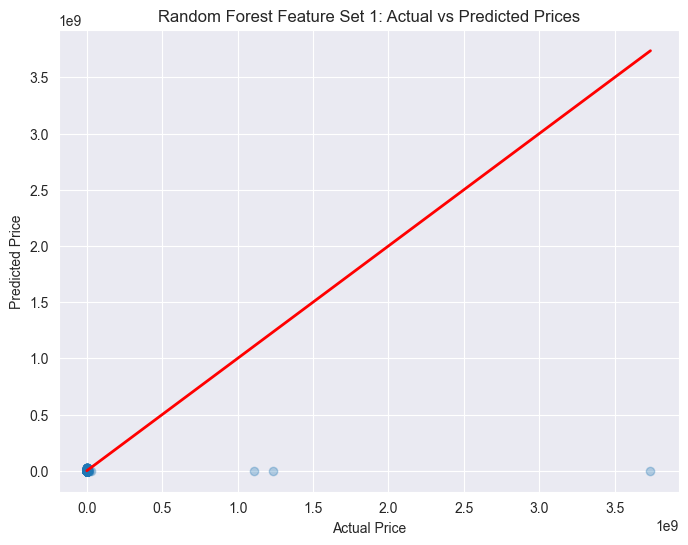

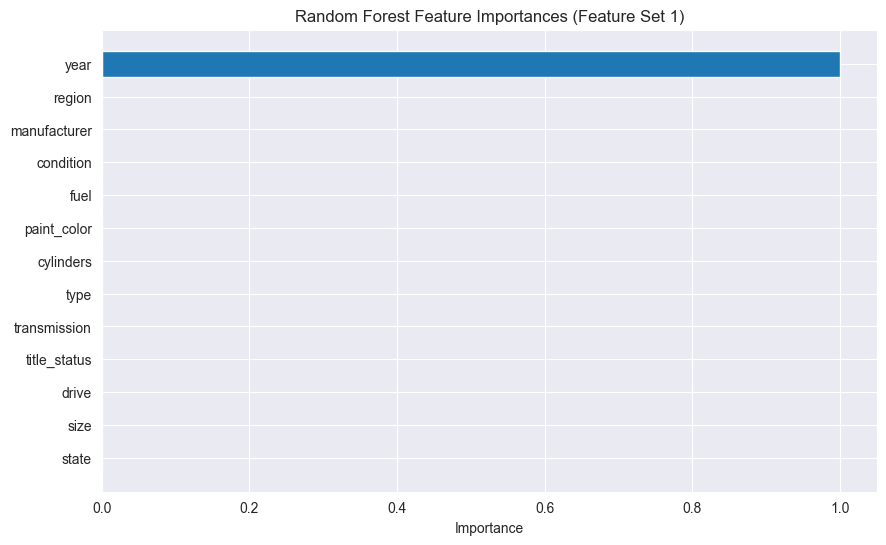

Random Forest Results for Feature Set 2:
MSE: 209492479728469.38, R2: -0.0693
 Feature_Set          MSE        R2
           2 2.094925e+14 -0.069294
Feature Importances:
     Feature  Importance
       model    0.771748
        year    0.228252
      region    0.000000
manufacturer    0.000000
   condition    0.000000
        fuel    0.000000
 paint_color    0.000000
   cylinders    0.000000
        type    0.000000
transmission    0.000000
title_status    0.000000
       drive    0.000000
        size    0.000000
       state    0.000000


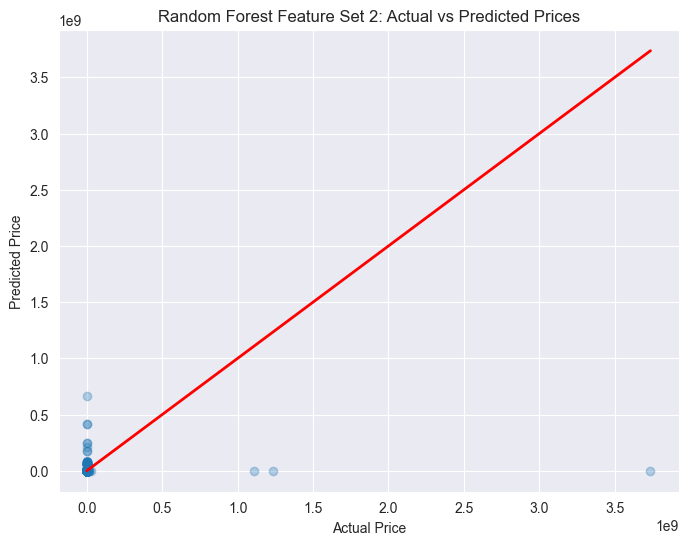

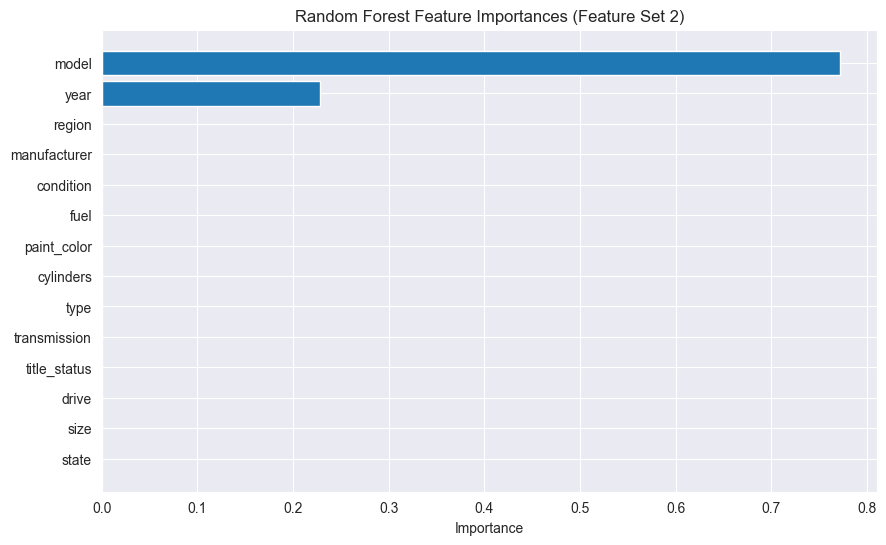

Random Forest Results for Feature Set 3:
MSE: 209492480418609.22, R2: -0.0693
 Feature_Set          MSE        R2
           3 2.094925e+14 -0.069294
Feature Importances:
     Feature  Importance
       model    0.771748
        year    0.228252
manufacturer    0.000000
   condition    0.000000
        fuel    0.000000
 paint_color    0.000000
   cylinders    0.000000
        type    0.000000
transmission    0.000000
title_status    0.000000
       drive    0.000000
        size    0.000000
       state    0.000000


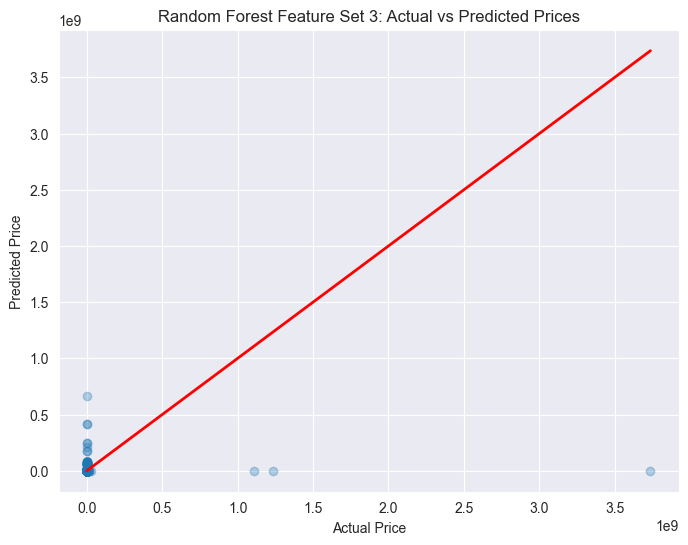

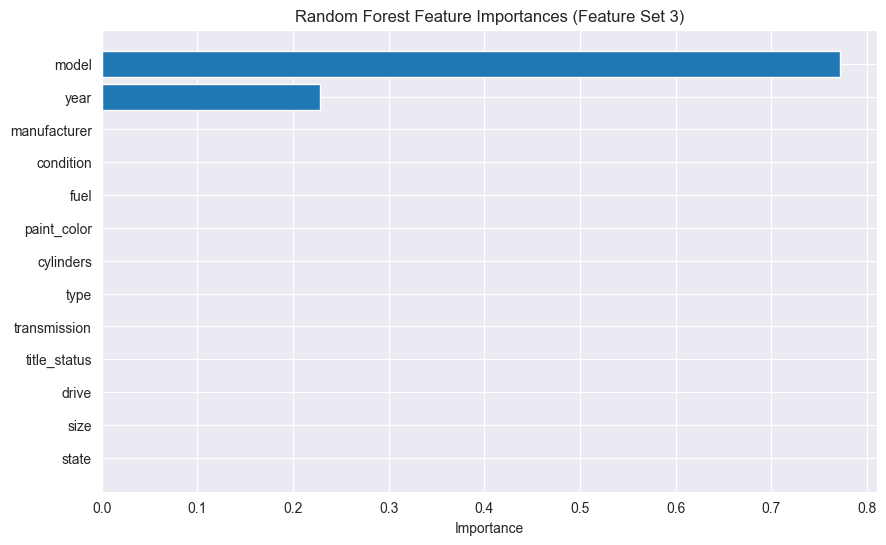

In [430]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Feature sets
rf_feature_sets = [
    ['region', 'manufacturer', 'condition', 'fuel', 'paint_color', 'year', 'cylinders', 'type', 'transmission', 'title_status', 'drive', 'size', 'state'],
    ['model', 'region', 'manufacturer', 'condition', 'fuel', 'paint_color', 'year', 'cylinders', 'type', 'transmission', 'title_status', 'drive', 'size', 'state'],
    ['model', 'manufacturer', 'condition', 'fuel', 'paint_color', 'year', 'cylinders', 'type', 'transmission', 'title_status', 'drive', 'size', 'state']
]

for idx, features in enumerate(rf_feature_sets, 1):
    # Encode categorical columns to numeric
    for col in features:
        if data[col].dtype == 'object':
            data[col] = data[col].astype('category').cat.codes
    X = data[features]
    y = pd.to_numeric(data['price'], errors='coerce').fillna(0)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f'Random Forest Results for Feature Set {idx}:')
    print(f'MSE: {mse:.2f}, R2: {r2:.4f}')
    # Display MSE and R2 in a DataFrame
    rf_results_df = pd.DataFrame({'Feature_Set': [idx], 'MSE': [mse], 'R2': [r2]})
    print(rf_results_df.to_string(index=False))
    # Feature importance
    importances = rf.feature_importances_
    importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
    importance_df = importance_df.sort_values(by='Importance', ascending=False)
    print('Feature Importances:')
    print(importance_df.to_string(index=False))
    # Plot actual vs predicted prices
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, y_pred, alpha=0.3)
    plt.xlabel('Actual Price')
    plt.ylabel('Predicted Price')
    plt.title(f'Random Forest Feature Set {idx}: Actual vs Predicted Prices')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
    plt.grid(True)
    plt.show()
    # Plot feature importances
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df['Feature'], importance_df['Importance'])
    plt.xlabel('Importance')
    plt.title(f'Random Forest Feature Importances (Feature Set {idx})')
    plt.gca().invert_yaxis()
    plt.show()

### Outlier Detection in Model Predictions

#### Outlier for feature set 1 - ['region', 'manufacturer', 'condition', 'fuel', 'paint_color', 'year', 'cylinders', 'type', 'transmission', 'title_status', 'drive', 'size', 'state']

In [431]:
import numpy as np

# Outlier detection for Linear Regression Feature Set 1
residuals_lr1 = y1_test - y1_pred
std_lr1 = np.std(residuals_lr1)
mean_lr1 = np.mean(residuals_lr1)
outlier_mask_lr1 = np.abs(residuals_lr1 - mean_lr1) > 3 * std_lr1
outliers_lr1 = y1_test[outlier_mask_lr1]
print(f'Linear Regression Feature Set 1 Outliers (|residual| > 3 std): {len(outliers_lr1)}')
print(outliers_lr1)

Linear Regression Feature Set 1 Outliers (|residual| > 3 std): 3
29359     1111111111
356653    3736928711
153040    1234567890
Name: price, dtype: int64


In [432]:

# Ensure rf is defined before outlier detection
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X2_train, y2_train)
# Outlier detection for Random Forest Feature Set 1
residuals_rf1 = y2_test - rf.predict(X2_test)
std_rf1 = np.std(residuals_rf1)
mean_rf1 = np.mean(residuals_rf1)
outlier_mask_rf1 = np.abs(residuals_rf1 - mean_rf1) > 3 * std_rf1
outliers_rf1 = y2_test[outlier_mask_rf1]
print(f'Random Forest Feature Set 1 Outliers (|residual| > 3 std): {len(outliers_rf1)}')
print(outliers_rf1)

# Print outlier indices and feature values for Random Forest Feature Set 1
outlier_indices_rf1 = y2_test.index[outlier_mask_rf1]
outlier_features_rf1 = X2_test.loc[outlier_indices_rf1]
print(f'Random Forest Feature Set 1 Outliers (|residual| > 3 std): {len(outliers_rf1)}')
print('Outlier indices:', outlier_indices_rf1.tolist())
print('Outlier feature values:')
print(outlier_features_rf1)
print('Outlier target values:')
print(outliers_rf1)

Random Forest Feature Set 1 Outliers (|residual| > 3 std): 40
285246         14995
238431         12000
100911          4999
3775            8000
83644          11999
367462         17992
77118          18990
43194          17500
30728          15995
38068           7000
356783           400
58147           5995
394539             0
395385             0
29359     1111111111
57654           5995
356653    3736928711
57951           5995
396142         11700
30133              0
355512         11999
67266          17995
345322         13900
9696            4000
229157         71495
244991         13750
251847          4295
35508          15995
332880          4995
317129         18000
35850          22995
262801             0
29281           5500
29333          22995
118385         26900
379174             1
256813           199
416182          8000
204197          3500
153040    1234567890
Name: price, dtype: int64
Random Forest Feature Set 1 Outliers (|residual| > 3 std): 40
Outlier in

#### Outlier for feature set 2 - ['model', 'region', 'manufacturer', 'condition', 'fuel', 'paint_color', 'year', 'cylinders', 'type', 'transmission', 'title_status', 'drive', 'size', 'state']

In [433]:
import numpy as np

# Outlier analysis for Linear Regression Feature Set 2
residuals_lr2 = y2_test - y2_pred
std_lr2 = np.std(residuals_lr2)
mean_lr2 = np.mean(residuals_lr2)
outlier_mask_lr2 = np.abs(residuals_lr2 - mean_lr2) > 3 * std_lr2
outlier_indices_lr2 = y2_test.index[outlier_mask_lr2]
outlier_features_lr2 = X2_test.loc[outlier_indices_lr2]
outliers_lr2 = y2_test[outlier_mask_lr2]
print(f'Linear Regression Feature Set 2 Outliers (|residual| > 3 std): {len(outliers_lr2)}')
print('Outlier indices:', outlier_indices_lr2.tolist())
print('Outlier feature values:')
print(outlier_features_lr2)
print('Outlier target values:')
print(outliers_lr2)

Linear Regression Feature Set 2 Outliers (|residual| > 3 std): 3
Outlier indices: [29359, 356653, 153040]
Outlier feature values:
        model  region  manufacturer  condition  fuel  paint_color    year  \
29359   15636     0.0           0.0        0.0   0.0          0.0  1999.0   
356653   3201     0.0           0.0        0.0   0.0          0.0  1999.0   
153040  28315     0.0           0.0        0.0   0.0          0.0  2006.0   

        cylinders  type  transmission  title_status  drive  size  state  
29359         0.0   0.0           0.0           0.0    0.0   0.0    0.0  
356653        0.0   0.0           0.0           0.0    0.0   0.0    0.0  
153040        0.0   0.0           0.0           0.0    0.0   0.0    0.0  
Outlier target values:
29359     1111111111
356653    3736928711
153040    1234567890
Name: price, dtype: int64


In [434]:

# Outlier analysis for Linear Regression Feature Set 3
residuals_lr3 = y3_test - y3_pred
std_lr3 = np.std(residuals_lr3)
mean_lr3 = np.mean(residuals_lr3)
outlier_mask_lr3 = np.abs(residuals_lr3 - mean_lr3) > 3 * std_lr3
outlier_indices_lr3 = y3_test.index[outlier_mask_lr3]
outlier_features_lr3 = X3_test.loc[outlier_indices_lr3]
outliers_lr3 = y3_test[outlier_mask_lr3]
print(f'Linear Regression Feature Set 3 Outliers (|residual| > 3 std): {len(outliers_lr3)}')
print('Outlier indices:', outlier_indices_lr3.tolist())
print('Outlier feature values:')
print(outlier_features_lr3)
print('Outlier target values:')
print(outliers_lr3)

Linear Regression Feature Set 3 Outliers (|residual| > 3 std): 3
Outlier indices: [29359, 356653, 153040]
Outlier feature values:
        model  manufacturer  condition  fuel  paint_color    year  cylinders  \
29359   15636           0.0        0.0   0.0          0.0  1999.0        0.0   
356653   3201           0.0        0.0   0.0          0.0  1999.0        0.0   
153040  28315           0.0        0.0   0.0          0.0  2006.0        0.0   

        type  transmission  title_status  drive  size  state  
29359    0.0           0.0           0.0    0.0   0.0    0.0  
356653   0.0           0.0           0.0    0.0   0.0    0.0  
153040   0.0           0.0           0.0    0.0   0.0    0.0  
Outlier target values:
29359     1111111111
356653    3736928711
153040    1234567890
Name: price, dtype: int64


In [435]:

# Random Forest for Feature Set 2
rf2 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf2.fit(X2_train, y2_train)
rf2_pred = rf2.predict(X2_test)
residuals_rf2 = y2_test - rf2_pred
std_rf2 = np.std(residuals_rf2)
mean_rf2 = np.mean(residuals_rf2)
outlier_mask_rf2 = np.abs(residuals_rf2 - mean_rf2) > 3 * std_rf2
outlier_indices_rf2 = y2_test.index[outlier_mask_rf2]
outlier_features_rf2 = X2_test.loc[outlier_indices_rf2]
outliers_rf2 = y2_test[outlier_mask_rf2]
print(f'Random Forest Feature Set 2 Outliers (|residual| > 3 std): {len(outliers_rf2)}')
print('Outlier indices:', outlier_indices_rf2.tolist())
print('Outlier feature values:')
print(outlier_features_rf2)
print('Outlier target values:')
print(outliers_rf2)

Random Forest Feature Set 2 Outliers (|residual| > 3 std): 40
Outlier indices: [285246, 238431, 100911, 3775, 83644, 367462, 77118, 43194, 30728, 38068, 356783, 58147, 394539, 395385, 29359, 57654, 356653, 57951, 396142, 30133, 355512, 67266, 345322, 9696, 229157, 244991, 251847, 35508, 332880, 317129, 35850, 262801, 29281, 29333, 118385, 379174, 256813, 416182, 204197, 153040]
Outlier feature values:
        model  region  manufacturer  condition  fuel  paint_color    year  \
285246  27770     0.0           0.0        0.0   0.0          0.0  2007.0   
238431  27982     0.0           0.0        0.0   0.0          0.0  1960.0   
100911   8978     0.0           0.0        0.0   0.0          0.0  2000.0   
3775    28514     0.0           0.0        0.0   0.0          0.0  1989.0   
83644   27770     0.0           0.0        0.0   0.0          0.0  2007.0   
367462  27770     0.0           0.0        0.0   0.0          0.0  2007.0   
77118   27770     0.0           0.0        0.0   0.0    

In [436]:

# Random Forest for Feature Set 3
rf3 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf3.fit(X3_train, y3_train)
rf3_pred = rf3.predict(X3_test)
residuals_rf3 = y3_test - rf3_pred
std_rf3 = np.std(residuals_rf3)
mean_rf3 = np.mean(residuals_rf3)
outlier_mask_rf3 = np.abs(residuals_rf3 - mean_rf3) > 3 * std_rf3
outlier_indices_rf3 = y3_test.index[outlier_mask_rf3]
outlier_features_rf3 = X3_test.loc[outlier_indices_rf3]
outliers_rf3 = y3_test[outlier_mask_rf3]
print(f'Random Forest Feature Set 3 Outliers (|residual| > 3 std): {len(outliers_rf3)}')
print('Outlier indices:', outlier_indices_rf3.tolist())
print('Outlier feature values:')
print(outlier_features_rf3)
print('Outlier target values:')
print(outliers_rf3)


Random Forest Feature Set 3 Outliers (|residual| > 3 std): 40
Outlier indices: [285246, 238431, 100911, 3775, 83644, 367462, 77118, 43194, 30728, 38068, 356783, 58147, 394539, 395385, 29359, 57654, 356653, 57951, 396142, 30133, 355512, 67266, 345322, 9696, 229157, 244991, 251847, 35508, 332880, 317129, 35850, 262801, 29281, 29333, 118385, 379174, 256813, 416182, 204197, 153040]
Outlier feature values:
        model  manufacturer  condition  fuel  paint_color    year  cylinders  \
285246  27770           0.0        0.0   0.0          0.0  2007.0        0.0   
238431  27982           0.0        0.0   0.0          0.0  1960.0        0.0   
100911   8978           0.0        0.0   0.0          0.0  2000.0        0.0   
3775    28514           0.0        0.0   0.0          0.0  1989.0        0.0   
83644   27770           0.0        0.0   0.0          0.0  2007.0        0.0   
367462  27770           0.0        0.0   0.0          0.0  2007.0        0.0   
77118   27770           0.0        